# Load Images #

In [3]:
# step1_tidy.py
# ─────────────────────────────────────────────────────────────────
# What this does:
#   1. Renames person folders to clean canonical names
#      (strips whitespace, fixes capitalisation)
#   2. Converts every image to .jpg  (handles .png, .JPEG, .JPG etc.)
#   3. Renames all files to a clean zero-padded sequence
#      e.g.  img1.jpg / IMG_3233.jpg / Joe_Olivetti1.jpg → 001.jpg
#   4. Removes the original non-jpg files after conversion
#   5. Prints a summary table at the end
#
# Run from the folder that CONTAINS photos_final/
# ─────────────────────────────────────────────────────────────────

import os
import shutil
from pathlib import Path
from PIL import Image

# ── CONFIG ───────────────────────────────────────────────────────
INPUT_ROOT  = Path("photos_final")
OUTPUT_ROOT = Path("photos_clean")       # new clean copy; original untouched
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
JPEG_QUALITY = 95

# Canonical name mapping  →  strip + title-case handles most cases,
# but explicit overrides catch edge cases like "roy" → "Roy"
NAME_OVERRIDES = {
    # "folder name as-is": "canonical name"
    # Add any that title-case gets wrong (acronyms, etc.)
}

# ─────────────────────────────────────────────────────────────────

def canonical_name(raw: str) -> str:
    stripped = raw.strip()
    if stripped in NAME_OVERRIDES:
        return NAME_OVERRIDES[stripped]
    return stripped.title()   # "roy" → "Roy", "Mikail " → "Mikail"


def to_jpg(src_path: Path, dst_path: Path, quality: int = JPEG_QUALITY):
    """Convert any image format to JPEG and save to dst_path."""
    img = Image.open(src_path).convert("RGB")   # RGB drops alpha channel safely
    img.save(dst_path, "JPEG", quality=quality)


def collect_images(folder: Path) -> list[Path]:
    """Recursively find all valid image files under folder."""
    found = []
    for p in sorted(folder.rglob("*")):
        if p.is_file() and p.suffix in VALID_EXTS:
            found.append(p)
    return found


# ── Main ─────────────────────────────────────────────────────────
OUTPUT_ROOT.mkdir(exist_ok=True)

summary = []   # (canonical_name, n_images)

# Gather all person folders, group by canonical name
# (handles "Jasper" + "Jasper " → same bucket)
buckets: dict[str, list[Path]] = {}

for entry in sorted(INPUT_ROOT.iterdir()):
    if not entry.is_dir():
        continue
    name = canonical_name(entry.name)
    if name not in buckets:
        buckets[name] = []
    buckets[name] += collect_images(entry)

# Process each person
for name, img_paths in sorted(buckets.items()):
    out_dir = OUTPUT_ROOT / name
    out_dir.mkdir(exist_ok=True)

    converted = 0
    skipped   = 0

    for idx, src in enumerate(img_paths, start=1):
        dst = out_dir / f"{idx:03d}.jpg"
        try:
            to_jpg(src, dst)
            converted += 1
        except Exception as e:
            print(f"  [ERROR] {src.name}: {e}")
            skipped += 1

    summary.append((name, converted, skipped))
    print(f"  {name:<12}  {converted:>3} images saved  ({skipped} skipped)")

# ── Summary table ────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"  {'Person':<12}  {'Saved':>6}  {'Skipped':>7}")
print(f"{'─'*45}")
total = 0
for name, saved, skipped in summary:
    flag = "  ⚠ low" if saved < 10 else ""
    print(f"  {name:<12}  {saved:>6}  {skipped:>7}{flag}")
    total += saved
print(f"{'─'*45}")
print(f"  {'TOTAL':<12}  {total:>6}")
print(f"\nOutput written to: {OUTPUT_ROOT.resolve()}")
print("Original photos_final/ is untouched.")

  Fathiah        15 images saved  (0 skipped)
  Fazil          17 images saved  (0 skipped)
  Jasper         16 images saved  (0 skipped)
  Joe            20 images saved  (0 skipped)
  Mikail         21 images saved  (0 skipped)
  Roy            23 images saved  (0 skipped)
  Syarah         31 images saved  (0 skipped)

─────────────────────────────────────────────
  Person         Saved  Skipped
─────────────────────────────────────────────
  Fathiah           15        0
  Fazil             17        0
  Jasper            16        0
  Joe               20        0
  Mikail            21        0
  Roy               23        0
  Syarah            31        0
─────────────────────────────────────────────
  TOTAL            143

Output written to: /Users/fazil/Desktop/EE4228/IE4228-Assignment/[FINAL] Assignment 1/photos_clean
Original photos_final/ is untouched.


## Data Preprocessing ##

In [4]:
# preprocess_functions.py
# ─────────────────────────────────────────────────────────────────
# All preprocessing steps as standalone functions.
# Call them individually or chain them in order.
#
# Pipeline order:
#   1. load_image(path)
#   2. detect_face(img_bgr)
#   3. align_face(gray, x, y, w, h)
#   4. crop_face(gray, x, y, w, h, img_shape)
#   5. resize_face(face_gray)
#   6. normalize_lighting(face_gray)
#   7. apply_ellipse_mask(face_gray)
#   8. save_face(face_gray, out_path)
# ─────────────────────────────────────────────────────────────────

import cv2
import numpy as np
from pathlib import Path

# ── Cascades (loaded once at module level) ────────────────────────
_face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
_eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# ── CONFIG ────────────────────────────────────────────────────────
FACE_SIZE       = (90, 90)
CLAHE_CLIP      = 2.0
CLAHE_GRID      = (8, 8)
FOREHEAD_EXTRA  = 0.15   # fraction of h to add above face box
CHIN_EXTRA      = 0.05   # fraction of h to add below face box
MAX_TILT_ANGLE  = 30.0   # degrees; skip rotation if tilt exceeds this


# ═════════════════════════════════════════════════════════════════
# STEP 1 — Load image
# ═════════════════════════════════════════════════════════════════
def load_image(path: str | Path) -> np.ndarray | None:
    """
    Load an image from disk and return as BGR numpy array.

    Returns None if the file cannot be read.

    Usage:
        img = load_image("photos_clean/Roy/001.jpg")
        if img is None:
            print("Could not load image")
    """
    img = cv2.imread(str(path))
    if img is None:
        print(f"  [load_image] Could not read: {path}")
    return img


# ═════════════════════════════════════════════════════════════════
# STEP 2 — Detect face (Viola-Jones)
# ═════════════════════════════════════════════════════════════════
def detect_face(img_bgr: np.ndarray) -> tuple | None:
    """
    Detect the largest face in a BGR image using Viola-Jones (Haar cascade).

    Tries progressively looser detection params until a face is found.
    Returns (x, y, w, h) of the largest detected face, or None.

    Why progressively looser:
        scaleFactor=1.05 is tight — catches more faces but slower.
        We try tight first, loosen only if nothing found.
        minNeighbors=4 avoids false positives in cluttered backgrounds.

    Usage:
        face_rect = detect_face(img)
        if face_rect is None:
            print("No face found")
        else:
            x, y, w, h = face_rect
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    for (scale, neighbors) in [(1.05, 4), (1.1, 4), (1.15, 3), (1.2, 2)]:
        faces = _face_cascade.detectMultiScale(
            gray,
            scaleFactor=scale,
            minNeighbors=neighbors,
            minSize=(40, 40)
        )
        if len(faces) > 0:
            # Pick the largest detection — most likely the primary face
            faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
            return tuple(faces[0])   # (x, y, w, h)

    print("  [detect_face] No face detected")
    return None


# ═════════════════════════════════════════════════════════════════
# STEP 3 — Align face (rotation correction via eye detection)
# ═════════════════════════════════════════════════════════════════
def align_face(
    gray: np.ndarray,
    x: int, y: int, w: int, h: int
) -> tuple[np.ndarray, int, int, int, int]:
    """
    Correct head tilt by detecting both eyes and rotating the full
    grayscale image so the eye line becomes horizontal.

    Searches for eyes only in the TOP HALF of the face bounding box
    (avoids false positives from nostrils and mouth).

    Sanity checks before rotating:
        - Requires exactly 2 eye candidates
        - Eyes must be separated by at least 20% of face width
          (rejects noise detections that are too close together)
        - Tilt must be < MAX_TILT_ANGLE degrees
          (large angles usually mean a bad eye detection)

    Returns (aligned_gray, x, y, w, h).
    If alignment fails any check, returns the original gray UNCHANGED
    — the face rect is still valid for cropping.

    Usage:
        aligned, x, y, w, h = align_face(gray, x, y, w, h)
        # aligned is the full rotated grayscale image
        # x,y,w,h still valid for cropping from aligned
    """
    face_roi = gray[y: y + h // 2, x: x + w]   # top half only

    eyes = _eye_cascade.detectMultiScale(
        face_roi,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(15, 15)
        # no maxSize — kills detection on small/close-up faces
    )

    if len(eyes) < 2:
        print(f"  [align_face] < 2 eyes found — skipping rotation")
        return gray, x, y, w, h

    # Take the two largest eye candidates
    eyes = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)[:2]
    eyes = sorted(eyes, key=lambda e: e[0])   # left → right by x

    (ex1, ey1, ew1, eh1) = eyes[0]
    (ex2, ey2, ew2, eh2) = eyes[1]

    # Reconstruct full-image coordinates
    # face_roi starts at (x, y) in the full image
    left_eye_center  = (x + ex1 + ew1 // 2,  y + ey1 + eh1 // 2)
    right_eye_center = (x + ex2 + ew2 // 2,  y + ey2 + eh2 // 2)

    # Sanity: eyes must be far enough apart
    eye_gap = abs(right_eye_center[0] - left_eye_center[0])
    if eye_gap < w * 0.20:
        print(f"  [align_face] Eyes too close ({eye_gap}px) — skipping rotation")
        return gray, x, y, w, h

    # Compute tilt angle
    dx    = right_eye_center[0] - left_eye_center[0]
    dy    = right_eye_center[1] - left_eye_center[1]
    angle = np.degrees(np.arctan2(dy, dx))

    if abs(angle) > MAX_TILT_ANGLE:
        print(f"  [align_face] Tilt {angle:.1f}° > {MAX_TILT_ANGLE}° — skipping rotation")
        return gray, x, y, w, h

    # Rotate around the midpoint between the eyes
# In align_face(), replace the eye_mid block:

    eye_mid = (
        float((left_eye_center[0] + right_eye_center[0]) // 2),
        float((left_eye_center[1] + right_eye_center[1]) // 2)
    )
    M       = cv2.getRotationMatrix2D(eye_mid, angle, 1.0)
    aligned = cv2.warpAffine(
        gray, M, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE   # fills gaps with edge pixels
    )

    print(f"  [align_face] Rotated {angle:.1f}°")
    return aligned, x, y, w, h


# ═════════════════════════════════════════════════════════════════
# STEP 4 — Crop face region
# ═════════════════════════════════════════════════════════════════
def crop_face(
    gray: np.ndarray,
    x: int, y: int, w: int, h: int
) -> np.ndarray | None:
    """
    Crop the face region from the (possibly aligned) grayscale image.

    Uses Olivetti-style asymmetric margins:
        - Forehead: +15% of h  (foreheads add discriminative info)
        - Chin:     + 5% of h  (chins vary more; keep tight)
        - Sides:      0% extra (Viola-Jones box already covers ears)

    Clamps all coordinates to image bounds before slicing.
    Returns the cropped grayscale face, or None if crop is empty.

    Usage:
        face_crop = crop_face(aligned_gray, x, y, w, h)
        if face_crop is None:
            print("Empty crop — skip this image")
    """
    img_h, img_w = gray.shape[:2]

    forehead = int(h * FOREHEAD_EXTRA)
    chin     = int(h * CHIN_EXTRA)

    x1 = max(0,     x)
    y1 = max(0,     y - forehead)
    x2 = min(img_w, x + w)
    y2 = min(img_h, y + h + chin)

    crop = gray[y1:y2, x1:x2]

    if crop.size == 0:
        print("  [crop_face] Empty crop — skipping")
        return None

    return crop


# ═════════════════════════════════════════════════════════════════
# STEP 5 — Resize to standard size
# ═════════════════════════════════════════════════════════════════
def resize_face(face_gray: np.ndarray, size: tuple = FACE_SIZE) -> np.ndarray:
    """
    Resize face crop to the standard size (default 90×90).

    Uses INTER_AREA interpolation — averages pixel blocks when
    downsampling, which reduces aliasing better than INTER_LINEAR.

    All training AND live-camera faces must go through this same
    function to guarantee identical dimensions for Fisherfaces.

    Usage:
        resized = resize_face(face_crop)          # → (90, 90)
        resized = resize_face(face_crop, (112,112))  # custom size
    """
    return cv2.resize(face_gray, size, interpolation=cv2.INTER_AREA)


# ═════════════════════════════════════════════════════════════════
# STEP 6 — Normalize lighting (CLAHE + min-max stretch)
# ═════════════════════════════════════════════════════════════════
def normalize_lighting(face_gray: np.ndarray) -> np.ndarray:
    """
    Two-stage illumination normalization:

    Stage A — CLAHE (Contrast Limited Adaptive Histogram Equalization):
        Divides the image into 8×8 tiles and equalizes each tile
        independently. The clipLimit=2.0 prevents over-amplifying
        noise in flat regions (e.g. forehead, cheeks).
        This corrects LOCAL lighting variation (one-sided light,
        shadows from nose/brow).

    Stage B — cv2.normalize (global min-max stretch):
        Stretches pixel values to the full [0, 255] range.
        Corrects GLOBAL brightness offset (e.g. dim overall image).

    Why both? CLAHE fixes contrast locally; normalize fixes
    the global offset. Together they handle the most common
    lighting problems in phone selfies.

    Usage:
        normalized = normalize_lighting(resized_face)
    """
    clahe      = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    clahe_img  = clahe.apply(face_gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized


# ═════════════════════════════════════════════════════════════════
# STEP 7 — Ellipse mask
# ═════════════════════════════════════════════════════════════════
def apply_ellipse_mask(face_gray: np.ndarray) -> np.ndarray:
    """
    Zero out pixels outside an oval region centred on the face.

    Why: Even after a tight Viola-Jones crop, the four corners
    contain background (wall, hair edges, clothing collar).
    PCA treats every pixel equally — corner background pixels
    add variance that has nothing to do with identity.
    The ellipse removes them cleanly.

    Axes are tuned for a 90×90 face:
        rx = 45% of width  → covers cheeks to ears
        ry = 48% of height → covers forehead to chin

    Pixels outside the ellipse are set to 0 (black).

    Usage:
        masked = apply_ellipse_mask(normalized_face)
    """
    h, w  = face_gray.shape
    mask  = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(
        mask,
        center=(w // 2, h // 2),
        axes=(int(w * 0.45), int(h * 0.48)),
        angle=0, startAngle=0, endAngle=360,
        color=255, thickness=-1   # filled ellipse
    )
    result = face_gray.copy()
    result[mask == 0] = 0
    return result


# ═════════════════════════════════════════════════════════════════
# STEP 8 — Save processed face
# ═════════════════════════════════════════════════════════════════
def save_face(face_gray: np.ndarray, out_path: str | Path) -> bool:
    """
    Save a processed grayscale face image to disk.

    Creates parent directories if they don't exist.
    Returns True on success, False on failure.

    Usage:
        save_face(masked_face, "processed_gallery/Roy/001.png")
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(str(out_path), face_gray)
    if not ok:
        print(f"  [save_face] Failed to write: {out_path}")
    return ok

In [5]:
fazil = load_image("/Users/fazil/Desktop/EE4228/IE4228-Assignment/[FINAL] Assignment 1/photos_clean/Fazil/011.jpg")

In [7]:
fazil_face = detect_face(fazil)

In [15]:
gray = cv2.cvtColor(fazil, cv2.COLOR_BGR2GRAY)
x, y, w, h = fazil_face
aligned, x, y, w, h = align_face(gray, x, y, w, h)

# Visualise before vs after alignment
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray[y:y+h, x:x+w], cmap="gray")
plt.title("Before alignment")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aligned[y:y+h, x:x+w], cmap="gray")
plt.title("After alignment")
plt.axis("off")

plt.tight_layout()
plt.show()

TypeError: Can't parse 'center'. Sequence item with index 0 has a wrong type

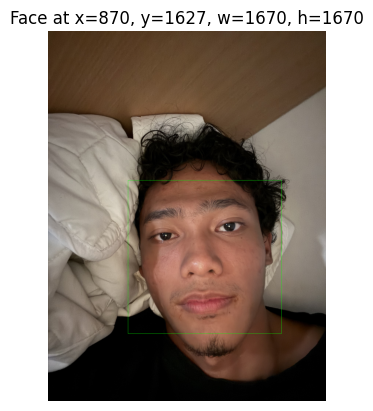

In [11]:
from matplotlib import pyplot as plt

if fazil_face is not None:
    x, y, w, h = fazil_face
    viz = fazil.copy()
    cv2.rectangle(viz, (x, y), (x+w, y+h), (0, 255, 0), 2)
    viz_rgb = cv2.cvtColor(viz, cv2.COLOR_BGR2RGB)  # matplotlib expects RGB
    plt.imshow(viz_rgb)
    plt.title(f"Face at x={x}, y={y}, w={w}, h={h}")
    plt.axis("off")
    plt.show()
else:
    print("No face detected")